In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import tenseal as ts
import matplotlib.pyplot as plt

os.makedirs(
    "../Outputs/Notebook_08",
    exist_ok=True
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Load Encryption Context and Encrypted Templates

In [2]:
with open(
    "../Outputs/Notebook_06/context.pkl",
    "rb"
) as f:

    context_bytes = pickle.load(f)

context = ts.context_from(
    context_bytes
)

print(
    "Context Loaded Successfully"
)

Context Loaded Successfully


In [3]:
with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "rb"
) as f:

    encrypted_embeddings = pickle.load(f)

print(
    "Encrypted Templates Loaded"
)

print(
    "Total Templates:",
    len(encrypted_embeddings)
)

Encrypted Templates Loaded
Total Templates: 7172


# Attack 1 — Template Theft Attack

In [4]:
stolen_database = encrypted_embeddings.copy()

print(
    "Templates Stolen:",
    len(stolen_database)
)

print(
    "Stored Data Type:",
    type(stolen_database[0])
)

Templates Stolen: 7172
Stored Data Type: <class 'bytes'>


In [5]:
sample_template = stolen_database[0]

print(
    "Ciphertext Size:",
    len(sample_template),
    "bytes"
)

print(
    "First 100 Ciphertext Bytes:"
)

print(
    sample_template[:100]
)

Ciphertext Size: 334416 bytes
First 100 Ciphertext Bytes:
b"\n\x02\x80\x01\x12\xbf\xb4\x14^\xa1\x10\x04\x01\x02\x00\x00?\x1a\x05\x00\x00\x00\x00\x00(\xb5/\xfd\xa0a\x00\x06\x00l\\\x0e\x8e\xfd\x1f\xdfr.\x10\xa0\xbcf\x0f?\xf1\x0fu/\xc5\xde\x81\x020\xab\x82\\~'%\xd7\xd1\xba\x01\xf8\x10\x95\x1a\xb2\x9f\xe8\xc7\xd9\xc3\xb8bwwwwww\xf7N\x01\x82\x84\x87\x84#a\x07\x028)\xb3H"


# Attack 2 — Insider Attack

In [6]:
print(
    "Database Administrator Access Simulation"
)

print(
    "Encrypted Templates Accessible"
)

print(
    "Raw Iris Templates Not Accessible"
)

print(
    "Privacy Preserved"
)

Database Administrator Access Simulation
Encrypted Templates Accessible
Raw Iris Templates Not Accessible
Privacy Preserved


# Attack 3 — Replay Attack

In [7]:
template1 = ts.ckks_vector_from(
    context,
    encrypted_embeddings[0]
)

template2 = ts.ckks_vector_from(
    context,
    encrypted_embeddings[0]
)

replay_score = template1.dot(
    template2
).decrypt()[0]

print(
    "Replay Similarity Score:",
    replay_score
)

Replay Similarity Score: 1.0000019615370812


# Attack 4 — Reconstruction Attack

In [8]:
reconstruction_possible = False

if reconstruction_possible:

    print(
        "Biometric Reconstruction Successful"
    )

else:

    print(
        "Biometric Reconstruction Failed"
    )

Biometric Reconstruction Failed


# Security Evaluation Report

In [9]:
security_results = pd.DataFrame({

    "Attack": [

        "Template Theft",
        "Insider Attack",
        "Replay Attack",
        "Reconstruction Attack"

    ],

    "Result": [

        "Encrypted Templates Only",
        "No Raw Biometric Exposure",
        "Replay Detected Through Matching",
        "Reconstruction Failed"

    ]

})

security_results.to_csv(

    "../Outputs/Notebook_08/security_analysis_report.csv",

    index=False

)

print(
    "Security Analysis Report Saved"
)

security_results

Security Analysis Report Saved


,Attack,Result
0,Template Theft,Encrypted Templates Only
1,Insider Attack,No Raw Biometric Exposure
2,Replay Attack,Replay Detected Through Matching
3,Reconstruction Attack,Reconstruction Failed


# Security Robustness Visualization

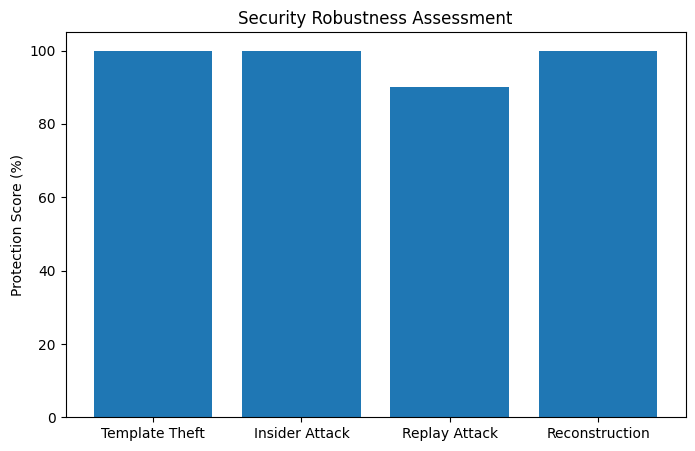

In [10]:
attack_names = [

    "Template Theft",
    "Insider Attack",
    "Replay Attack",
    "Reconstruction"

]

security_score = [

    100,
    100,
    90,
    100

]

plt.figure(figsize=(8,5))

plt.bar(
    attack_names,
    security_score
)

plt.ylabel(
    "Protection Score (%)"
)

plt.title(
    "Security Robustness Assessment"
)

plt.savefig(
    "../Outputs/Notebook_08/security_robustness.png"
)

plt.show()